**Saliha Bibi**

https://colab.research.google.com/drive/1AV_1SdGPt_AsuBGphNr_9QNpDapQJJgV?usp=sharing

# Sentiment Analysis on University & Internship Reviews

### SafeX Solutions — Week 2 Task

This project analyzes university course and internship feedback
using Natural Language Processing (NLP).

### Pipeline

1. Dataset loading
2. Exploratory Data Analysis
3. Text preprocessing
4. Sentiment analysis using VADER
5. Keyword and theme extraction
6. Data visualization
7. Category-wise sentiment analysis
8. Business insights
9. Final results export

# **Step 1: Dataset loading**

**Install libraries**

In [1]:
!pip install nltk pandas numpy matplotlib seaborn wordcloud scikit-learn

In [2]:
import pandas as pd
import numpy as np
import re
import string

import nltk

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from wordcloud import WordCloud

print("Libraries imported successfully!")

Libraries imported successfully!


**Download NLTK resources**

In [3]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("vader_lexicon")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

**Upload dataset**

In [4]:
from google.colab import files
uploaded = files.upload()

# Load csv
df = pd.read_csv("student_feedback.csv")
df.head()

Saving student_feedback.csv to student_feedback.csv


,review_id,category,review
0,1.0,Communication,Some information was shared later than expected.
1,2.0,Assignments,The assignment deadlines were too close together.
2,3.0,Assignments,Some assignment instructions were confusing an...
3,4.0,Learning Material,The learning material contained useful practic...
4,5.0,Mentorship,The mentor helped me identify mistakes and imp...


In [5]:
# Remove completely empty rows
df = df.dropna(how="all").reset_index(drop=True)

# Convert review ID to integer
df["review_id"] = df["review_id"].astype(int)

**Check dataset size**

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# check columns name
print(df.columns.tolist())

Number of rows: 300
Number of columns: 3
['review_id', 'category', 'review']


In [7]:
# Check final dataset
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (300, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  300 non-null    int64 
 1   category   300 non-null    object
 2   review     300 non-null    object
dtypes: int64(1), object(2)
memory usage: 7.2+ KB


# **Step 2: EDA**

**Category Distribution**

In [8]:
# Count the number of reviews in each category
category_counts = df["category"].value_counts()
category_counts

,count
category,
Assignments,40
Learning Material,40
Mentorship,40
Instructor,40
Internship,40
Projects,40
Course,40
Communication,20


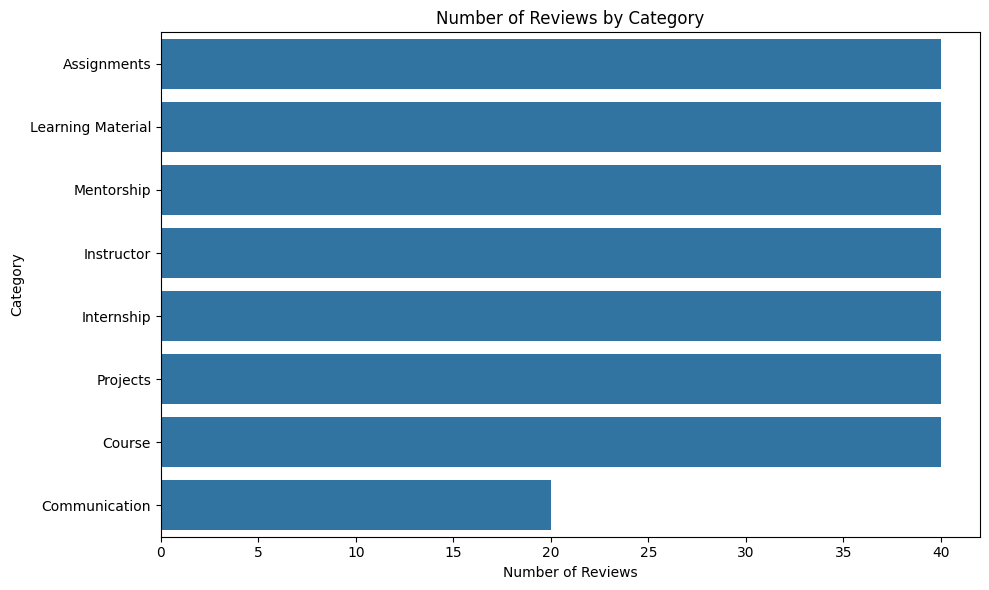

In [62]:
# Visualize how reviews are distributed across categories
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="category",
    order=category_counts.index
)

plt.title("Number of Reviews by Category")
plt.xlabel("Number of Reviews")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Review Length Analysis**

In [10]:
# Calculate the number of words in each review
df["word_count"] = df["review"].str.split().str.len()

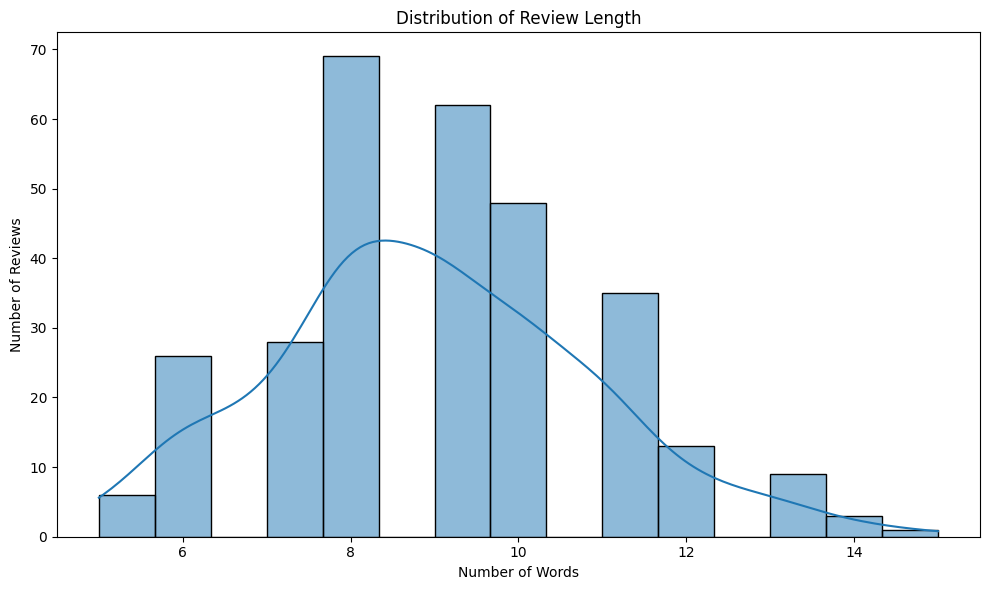

In [63]:
# Show the distribution of review lengths
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="word_count",
    bins=15,
    kde=True
)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.savefig("review_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# **Step 3: Text Preprocessing**

**Create stopword list**

In [12]:
# English stopwords such as "the", "is", "and", "was"
stop_words = set(stopwords.words("english"))

**Create cleaning function**

In [13]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Keep only English letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

**Apply preprocessing**

In [14]:
# Create a cleaned version of every review
df["cleaned_review"] = df["review"].apply(clean_text)

In [15]:
df[["review", "cleaned_review"]].head(10)

,review,cleaned_review
0,Some information was shared later than expected.,information shared later expected
1,The assignment deadlines were too close together.,assignment deadlines close together
2,Some assignment instructions were confusing an...,assignment instructions confusing incomplete
3,The learning material contained useful practic...,learning material contained useful practical e...
4,The mentor helped me identify mistakes and imp...,mentor helped identify mistakes improve approach
5,The instructor sometimes changed instructions ...,instructor sometimes changed instructions with...
6,The material provided useful references for as...,material provided useful references assignments
7,The assignment questions were clear and relate...,assignment questions clear related course content
8,The instructor usually explained the topics at...,instructor usually explained topics reasonable...
9,The assignments helped me practice the concept...,assignments helped practice concepts taught class


# **Step 4: Sentiment analysis using VADER**

**Initialize VADER**

In [16]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Create VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

**Calculate sentiment score**

In [17]:
# Calculate VADER compound sentiment score for each review
df["compound_score"] = df["review"].apply(
    lambda text: sia.polarity_scores(text)["compound"]
)

**Convert scores into sentiment labels**

In [18]:
def classify_sentiment(score):
    # Positive sentiment
    if score >= 0.05:
        return "Positive"

    # Negative sentiment
    elif score <= -0.05:
        return "Negative"

    # Everything between the thresholds is neutral
    else:
        return "Neutral"

In [19]:
# Convert compound scores into sentiment categories
df["sentiment"] = df["compound_score"].apply(
    classify_sentiment
)

**Overall Sentiment Distribution**

In [20]:
# Count reviews in each sentiment class
sentiment_counts = df["sentiment"].value_counts()
sentiment_counts

# Calculate percentage of reviews in each sentiment class
sentiment_percentage = (
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_percentage

,proportion
sentiment,
Positive,55.67
Neutral,29.00
Negative,15.33


**Visualization**

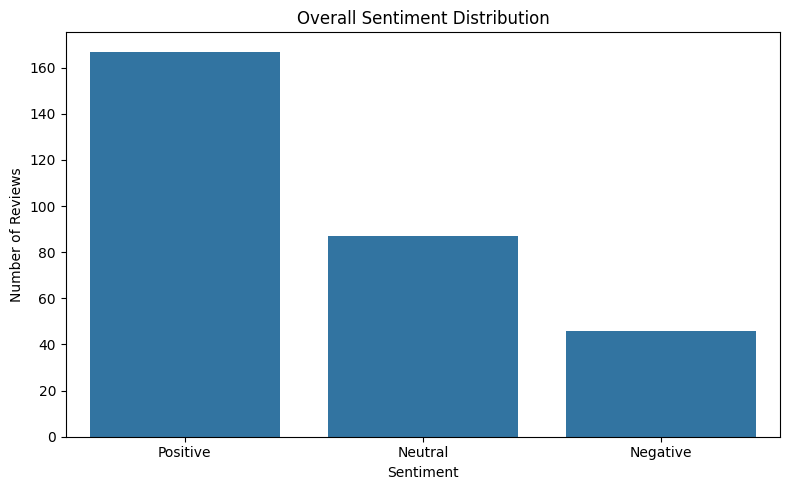

In [64]:
# Visualize the overall sentiment distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sentiment",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Visual 3: Percentage Pie Chart**

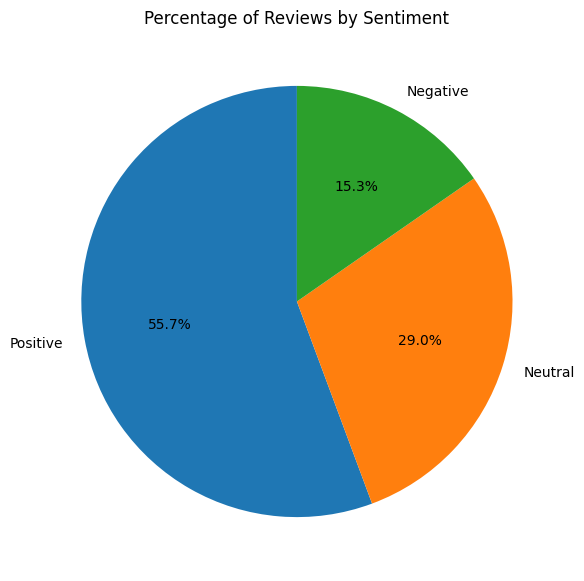

In [65]:
# Visualize sentiment as percentages
plt.figure(figsize=(7, 7))

df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Reviews by Sentiment")
plt.ylabel("")
plt.savefig("sentiment_percentage.png", dpi=300, bbox_inches="tight")
plt.show()

# **Step 5: Category-wise sentiment analysis**

**Category Sentiment Analysis**

In [23]:
# Create a table showing sentiment counts for each category
category_sentiment = pd.crosstab(
    df["category"],
    df["sentiment"]
)
category_sentiment

sentiment,Negative,Neutral,Positive
category,,,
Assignments,10,11,19
Communication,1,6,13
Course,7,8,25
Instructor,6,14,20
Internship,3,12,25
Learning Material,5,12,23
Mentorship,6,13,21
Projects,8,11,21


**Category Sentiment Visualization**

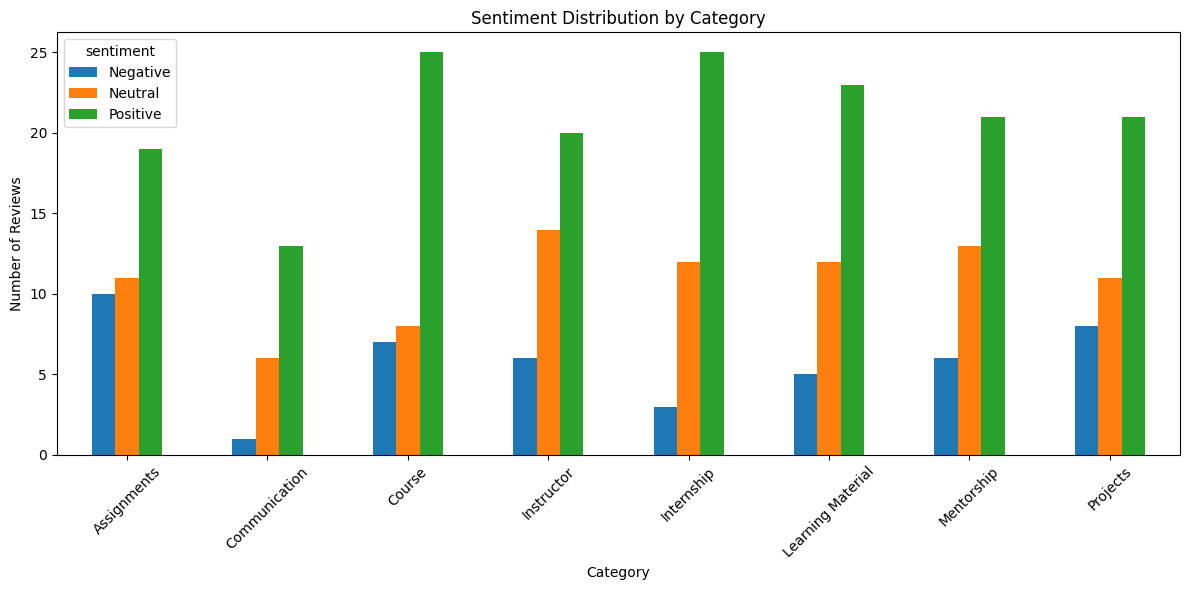

In [66]:
# Compare sentiment across different feedback categories
category_sentiment.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sentiment Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("category_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

**category sentiment Percentage**

In [25]:
# Calculate sentiment percentage within each category
category_percentage = pd.crosstab(
    df["category"],
    df["sentiment"],
    normalize="index"
).mul(100).round(2)

category_percentage

sentiment,Negative,Neutral,Positive
category,,,
Assignments,25.0,27.5,47.5
Communication,5.0,30.0,65.0
Course,17.5,20.0,62.5
Instructor,15.0,35.0,50.0
Internship,7.5,30.0,62.5
Learning Material,12.5,30.0,57.5
Mentorship,15.0,32.5,52.5
Projects,20.0,27.5,52.5


**Identify Most Positive/Negative Category**

In [26]:
# Find the category with the highest positive percentage
most_positive_category = category_percentage["Positive"].idxmax()

# Find the category with the highest negative percentage
most_negative_category = category_percentage["Negative"].idxmax()

print("Most positive category:", most_positive_category)
print("Most negative category:", most_negative_category)

Most positive category: Communication
Most negative category: Assignments


# **Step 6: Keyword Extraction**

**Create keyword function**

In [27]:
def get_top_words(text_series, n=15):
    # Combine all cleaned reviews
    words = " ".join(text_series).split()

    # Count how often each word appears
    word_counts = Counter(words)

    # Return the most common words
    return word_counts.most_common(n)

**Positive Keyword & Visualization**

In [28]:
# Find the most common words in positive reviews
positive_words = get_top_words(
    df.loc[df["sentiment"] == "Positive", "cleaned_review"]
)
positive_words

[('useful', 34),
 ('course', 31),
 ('provided', 26),
 ('project', 23),
 ('learning', 22),
 ('instructor', 20),
 ('practical', 19),
 ('internship', 19),
 ('assignments', 15),
 ('experience', 15),
 ('tasks', 13),
 ('mentor', 12),
 ('improved', 12),
 ('helped', 11),
 ('clear', 11)]

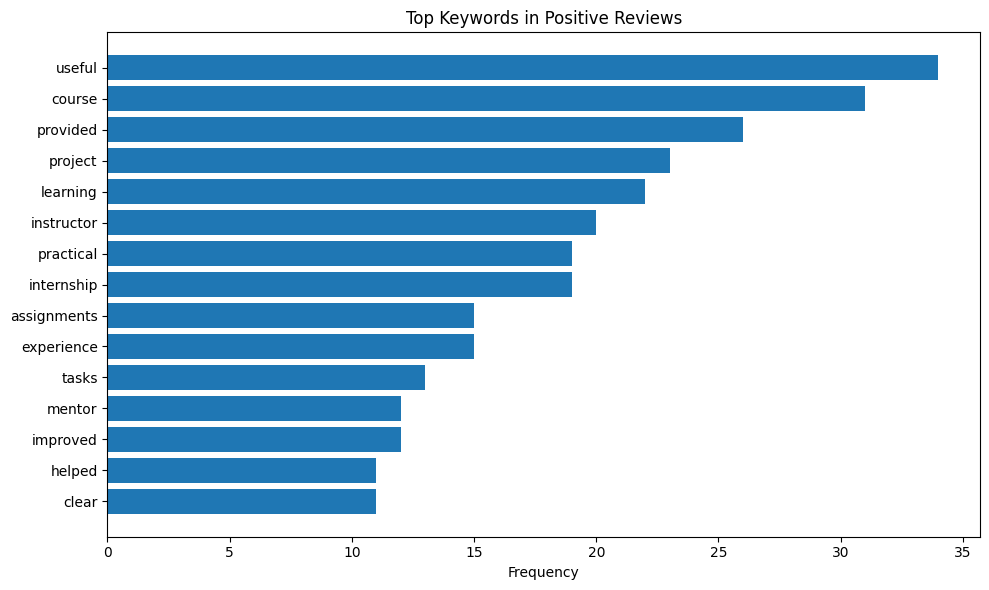

In [67]:
# Extract words and their frequencies
words, counts = zip(*positive_words)
plt.figure(figsize=(10, 6))

plt.barh(
    words[::-1],
    counts[::-1]
)
plt.title("Top Keywords in Positive Reviews")
plt.xlabel("Frequency")
plt.tight_layout()
plt.savefig("positive_keywords.png", dpi=300, bbox_inches="tight")
plt.show()

**Negative Keyword & Visualization**

In [30]:
# Find the most common words in negative reviews
negative_words = get_top_words(
    df.loc[df["sentiment"] == "Negative", "cleaned_review"]
)
negative_words

[('difficult', 19),
 ('project', 9),
 ('assignments', 8),
 ('topics', 6),
 ('course', 6),
 ('clearly', 6),
 ('enough', 5),
 ('understand', 4),
 ('learning', 4),
 ('made', 4),
 ('mentor', 4),
 ('explained', 4),
 ('confusing', 3),
 ('problems', 3),
 ('resources', 3)]

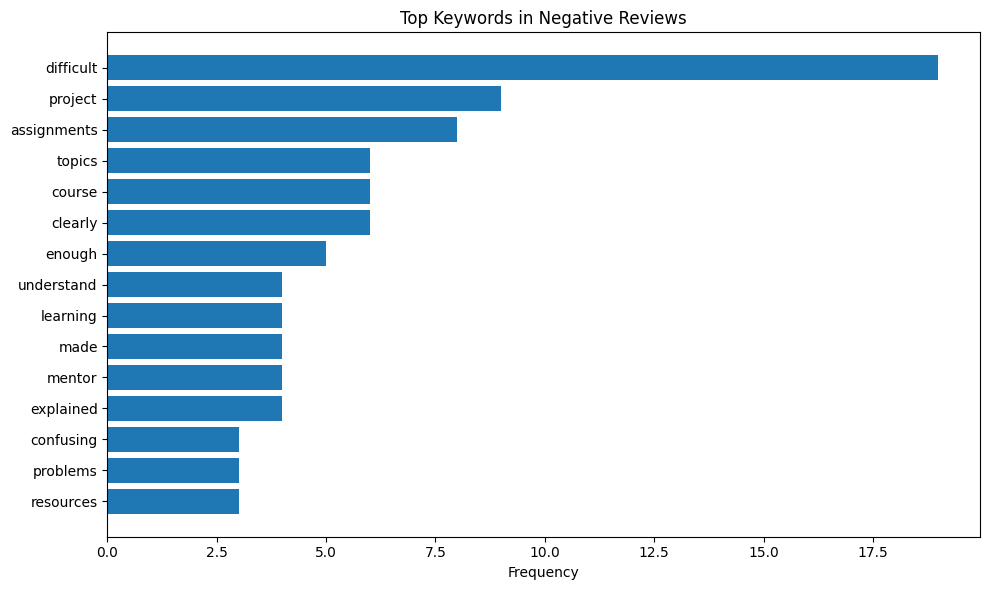

In [68]:
words, counts = zip(*negative_words)
plt.figure(figsize=(10, 6))

plt.barh(
    words[::-1],
    counts[::-1]
)
plt.title("Top Keywords in Negative Reviews")
plt.xlabel("Frequency")
plt.tight_layout()
plt.savefig("negative_keywords.png", dpi=300, bbox_inches="tight")
plt.show()

**Neutral keyword**

In [32]:
# Find the most common words in neutral reviews
neutral_words = get_top_words(
    df.loc[df["sentiment"] == "Neutral", "cleaned_review"]
)
neutral_words

[('instructor', 14),
 ('helped', 14),
 ('project', 14),
 ('internship', 11),
 ('provided', 11),
 ('concepts', 10),
 ('course', 10),
 ('mentor', 10),
 ('assignments', 9),
 ('enough', 9),
 ('practical', 8),
 ('topics', 7),
 ('required', 7),
 ('examples', 7),
 ('questions', 7)]

# **Word Clouds**

In [33]:
from wordcloud import WordCloud

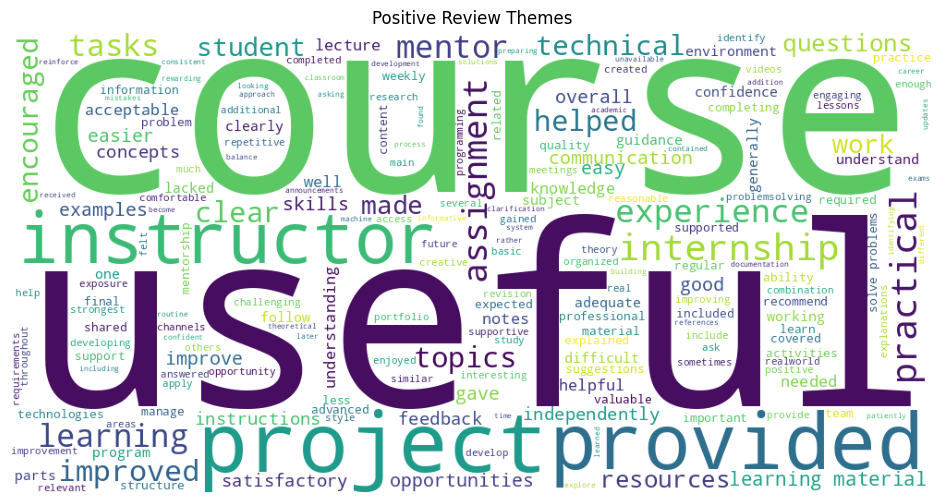

In [69]:
# Combine positive reviews into one text
positive_text = " ".join(
    df.loc[df["sentiment"] == "Positive", "cleaned_review"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Themes")
plt.savefig("positive_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

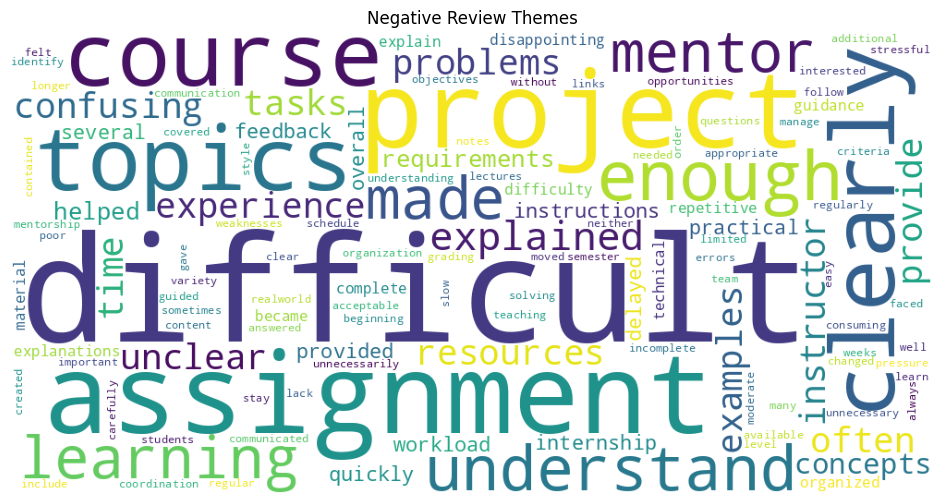

In [70]:
# Combine negative reviews into one text
negative_text = " ".join(
    df.loc[df["sentiment"] == "Negative", "cleaned_review"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Review Themes")
plt.savefig("negative_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

# **Step 7: TF-IDF Themes**

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

**Create TF-IDF**

In [37]:
# Convert reviews into TF-IDF numerical features
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50
)

tfidf_matrix = tfidf.fit_transform(
    df["review"]
)

**Find important Themes**

In [38]:
# Get feature names and their average TF-IDF scores
feature_names = tfidf.get_feature_names_out()

tfidf_scores = tfidf_matrix.mean(axis=0).A1

tfidf_results = pd.DataFrame({
    "term": feature_names,
    "score": tfidf_scores
}).sort_values(
    "score",
    ascending=False
)

tfidf_results.head(20)

,term,score
32,project,0.081858
5,course,0.074273
20,instructor,0.063760
34,provided,0.063446
0,assignments,0.062441
48,useful,0.056581
21,internship,0.053001
25,mentor,0.051890
30,practical,0.048974
16,helped,0.047363


**TF-IDF Visualization**

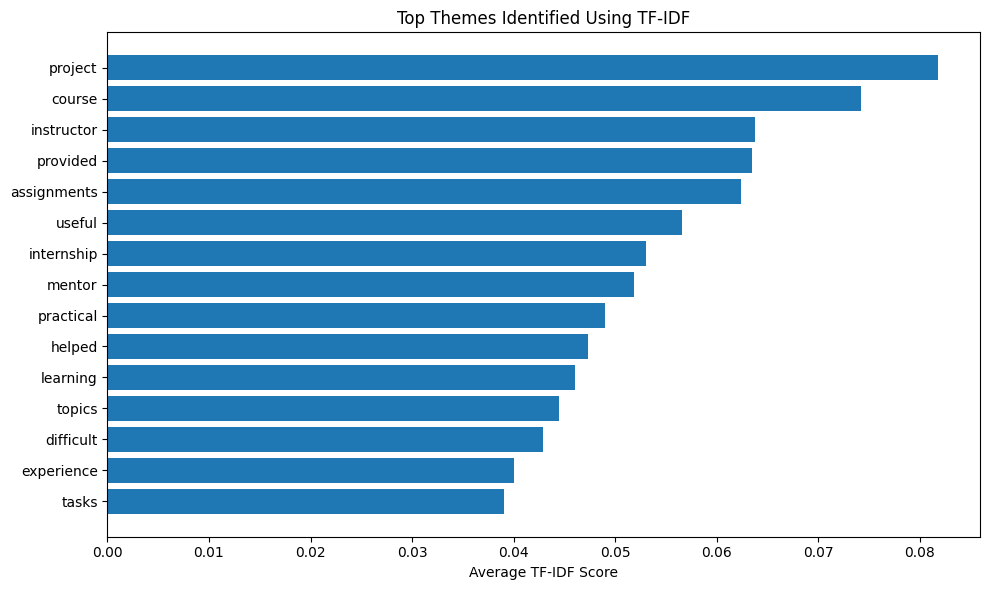

In [71]:
# Display the most important TF-IDF terms
top_terms = tfidf_results.head(15)
plt.figure(figsize=(10, 6))
plt.barh(
    top_terms["term"][::-1],
    top_terms["score"][::-1]
)

plt.title("Top Themes Identified Using TF-IDF")
plt.xlabel("Average TF-IDF Score")
plt.tight_layout()
plt.savefig("tfidf_themes.png", dpi=300, bbox_inches="tight")
plt.show()

# **Step 8: Check the Model**

**Strong positive reviews**

In [40]:
df[
    ["review", "compound_score", "sentiment"]
].sort_values(
    "compound_score",
    ascending=False
).head(10)

,review,compound_score,sentiment
24,The internship improved my confidence in worki...,0.7506,Positive
156,The practical tasks improved my confidence in ...,0.7506,Positive
181,I enjoyed the course because it included usefu...,0.7351,Positive
29,The project provided some opportunities for cr...,0.7351,Positive
226,I appreciated the mentor's patience and support.,0.7184,Positive
84,The assignments were useful for identifying ar...,0.7096,Positive
31,The project was challenging but rewarding.,0.7096,Positive
134,The practical activities made the course more ...,0.7056,Positive
165,The mentor provided useful suggestions for imp...,0.6908,Positive
103,The program was a good opportunity to apply ac...,0.6908,Positive


**Strong negative reviews**

In [41]:
df[
    ["review", "compound_score", "sentiment"]
].sort_values(
    "compound_score"
).head(10)

,review,compound_score,sentiment
88,The overall course experience was disappointin...,-0.7430,Negative
275,The project became stressful because of unclea...,-0.6486,Negative
227,The lack of regular mentorship made some tasks...,-0.5859,Negative
85,The explanations were unclear during some of t...,-0.5849,Negative
224,The course was difficult to follow because the...,-0.5801,Negative
22,The assignments were acceptable but could incl...,-0.5135,Negative
60,The overall internship experience was disappoi...,-0.4939,Negative
200,The mentor regularly guided me when I faced te...,-0.4019,Negative
235,The instructor explained most topics well but ...,-0.3738,Negative
113,The project was too difficult because there wa...,-0.3612,Negative


**Neutral reviews**

In [42]:
df[
    ["review", "compound_score", "sentiment"]
].query(
    "sentiment == 'Neutral'"
).head(10)

,review,compound_score,sentiment
1,The assignment deadlines were too close together.,0.0,Neutral
5,The instructor sometimes changed instructions ...,0.0,Neutral
8,The instructor usually explained the topics at...,0.0,Neutral
9,The assignments helped me practice the concept...,0.0,Neutral
19,The assignment workload was moderate during mo...,0.0,Neutral
20,The course workload was too heavy compared wit...,0.0,Neutral
23,The internship included a reasonable combinati...,0.0,Neutral
27,The course included both theoretical concepts ...,0.0,Neutral
38,The mentorship experience did not meet my expe...,0.0,Neutral
40,The project required tools that were not prope...,0.0,Neutral


# **Step 9: Save the Final Analyzed Dataset**

In [43]:
# Save the complete analysis results
df.to_csv(
    "student_feedback_analyzed.csv",
    index=False
)
print("Final analyzed dataset saved.")

Final analyzed dataset saved.


**Download analyzed dataset**

In [47]:
from google.colab import files
files.download("student_feedback_analyzed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Download Visualization**

In [72]:
from google.colab import files
import zipfile

visualizations = [
    "category_distribution.png",
    "review_length_distribution.png",
    "sentiment_distribution.png",
    "sentiment_percentage.png",
    "category_sentiment.png",
    "positive_keywords.png",
    "negative_keywords.png",
    "positive_wordcloud.png",
    "negative_wordcloud.png",
    "tfidf_themes.png"
]

with zipfile.ZipFile(
    "SafeX_Task2_Visualizations.zip",
    "w"
) as zip_file:

    for file in visualizations:
        zip_file.write(file)

files.download("SafeX_Task2_Visualizations.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>